## Criação do Agente por Código

In [0]:
%pip install -U -qqqq mlflow langchain langgraph==0.3.4 databricks-langchain pydantic databricks-agents unitycatalog-langchain[databricks] databricks-openai uv openai

dbutils.library.restartPython()

Note: you may need to restart the kernel using %restart_python or dbutils.library.restartPython() to use updated packages.


In [0]:
catalog = "baraldi_catalog_new"
schema = "genai"

In [0]:
%%writefile agent.py
import json
from typing import Annotated, Any, Generator, Optional, Sequence, TypedDict, Union
from uuid import uuid4

import mlflow
from databricks_langchain import (
    ChatDatabricks,
    UCFunctionToolkit,
    VectorSearchRetrieverTool,
)
from langchain_core.language_models import LanguageModelLike
from langchain_core.messages import (
    AIMessage,
    AIMessageChunk,
    BaseMessage,
    convert_to_openai_messages,
)
from langchain_core.runnables import RunnableConfig, RunnableLambda
from langchain_core.tools import BaseTool
from langgraph.graph import END, StateGraph
from langgraph.graph.message import add_messages
from langgraph.prebuilt.tool_node import ToolNode
from mlflow.entities import SpanType
from mlflow.pyfunc import ResponsesAgent
from mlflow.types.responses import (
    ResponsesAgentRequest,
    ResponsesAgentResponse,
    ResponsesAgentStreamEvent,
)

############################################
# Define your LLM endpoint and system prompt
############################################
# TODO: Replace with your model serving endpoint
# LLM_ENDPOINT_NAME = "databricks-claude-3-7-sonnet"
LLM_ENDPOINT_NAME = "databricks-claude-3-7-sonnet"
llm = ChatDatabricks(endpoint=LLM_ENDPOINT_NAME)

# TODO: Update with your system prompt
system_prompt = "You are a helpful assistant that can run Python code."

###############################################################################
## Define tools for your agent, enabling it to retrieve data or take actions
## beyond text generation
## To create and see usage examples of more tools, see
## https://docs.databricks.com/en/generative-ai/agent-framework/agent-tool.html
###############################################################################
tools = []

# You can use UDFs in Unity Catalog as agent tools
# Below, we add the `system.ai.python_exec` UDF, which provides
# a python code interpreter tool to our agent
# You can also add local LangChain python tools. See https://python.langchain.com/docs/concepts/tools

# TODO: Add additional tools
UC_TOOL_NAMES = ["system.ai.python_exec"]
uc_toolkit = UCFunctionToolkit(function_names=UC_TOOL_NAMES)
tools.extend(uc_toolkit.tools)

# Use Databricks vector search indexes as tools
# See https://docs.databricks.com/en/generative-ai/agent-framework/unstructured-retrieval-tools.html#locally-develop-vector-search-retriever-tools-with-ai-bridge
# List to store vector search tool instances for unstructured retrieval.
VECTOR_SEARCH_TOOLS = []

# To add vector search retriever tools,
# use VectorSearchRetrieverTool and create_tool_info,
# then append the result to TOOL_INFOS.
# Example:
# VECTOR_SEARCH_TOOLS.append(
#     VectorSearchRetrieverTool(
#         index_name="",
#         # filters="..."
#     )
# )

tools.extend(VECTOR_SEARCH_TOOLS)

#####################
## Define agent logic
#####################


class AgentState(TypedDict):
    messages: Annotated[Sequence[BaseMessage], add_messages]
    custom_inputs: Optional[dict[str, Any]]
    custom_outputs: Optional[dict[str, Any]]


def create_tool_calling_agent(
    model: LanguageModelLike,
    tools: Union[ToolNode, Sequence[BaseTool]],
    system_prompt: Optional[str] = None,
):
    model = model.bind_tools(tools)

    # Define the function that determines which node to go to
    def should_continue(state: AgentState):
        messages = state["messages"]
        last_message = messages[-1]
        # If there are function calls, continue. else, end
        if isinstance(last_message, AIMessage) and last_message.tool_calls:
            return "continue"
        else:
            return "end"

    if system_prompt:
        preprocessor = RunnableLambda(
            lambda state: [{"role": "system", "content": system_prompt}] + state["messages"]
        )
    else:
        preprocessor = RunnableLambda(lambda state: state["messages"])
    model_runnable = preprocessor | model

    def call_model(
        state: AgentState,
        config: RunnableConfig,
    ):
        response = model_runnable.invoke(state, config)

        return {"messages": [response]}

    workflow = StateGraph(AgentState)

    workflow.add_node("agent", RunnableLambda(call_model))
    workflow.add_node("tools", ToolNode(tools))

    workflow.set_entry_point("agent")
    workflow.add_conditional_edges(
        "agent",
        should_continue,
        {
            "continue": "tools",
            "end": END,
        },
    )
    workflow.add_edge("tools", "agent")

    return workflow.compile()


class LangGraphResponsesAgent(ResponsesAgent):
    def __init__(self, agent):
        self.agent = agent

    def _langchain_to_responses(self, messages: list[BaseMessage]) -> list[dict[str, Any]]:
        "Convert from ChatCompletion dict to Responses output item dictionaries"
        for message in messages:
            message = message.model_dump()
            role = message["type"]
            if role == "ai":
                if tool_calls := message.get("tool_calls"):
                    return [
                        self.create_function_call_item(
                            id=message.get("id") or str(uuid4()),
                            call_id=tool_call["id"],
                            name=tool_call["name"],
                            arguments=json.dumps(tool_call["args"]),
                        )
                        for tool_call in tool_calls
                    ]
                else:
                    return [
                        self.create_text_output_item(
                            text=message["content"],
                            id=message.get("id") or str(uuid4()),
                        )
                    ]
            elif role == "tool":
                return [
                    self.create_function_call_output_item(
                        call_id=message["tool_call_id"],
                        output=message["content"],
                    )
                ]
            elif role == "user":
                return [message]

    def predict(self, request: ResponsesAgentRequest) -> ResponsesAgentResponse:
        outputs = [
            event.item
            for event in self.predict_stream(request)
            if event.type == "response.output_item.done"
        ]
        return ResponsesAgentResponse(output=outputs, custom_outputs=request.custom_inputs)

    def predict_stream(
        self,
        request: ResponsesAgentRequest,
    ) -> Generator[ResponsesAgentStreamEvent, None, None]:
        cc_msgs = self.prep_msgs_for_cc_llm([i.model_dump() for i in request.input])

        for event in self.agent.stream({"messages": cc_msgs}, stream_mode=["updates", "messages"]):
            if event[0] == "updates":
                for node_data in event[1].values():
                    for item in self._langchain_to_responses(node_data["messages"]):
                        yield ResponsesAgentStreamEvent(type="response.output_item.done", item=item)
            # filter the streamed messages to just the generated text messages
            elif event[0] == "messages":
                try:
                    chunk = event[1][0]
                    if isinstance(chunk, AIMessageChunk) and (content := chunk.content):
                        yield ResponsesAgentStreamEvent(
                            **self.create_text_delta(delta=content, item_id=chunk.id),
                        )
                except Exception as e:
                    print(e)


# Create the agent object, and specify it as the agent object to use when
# loading the agent back for inference via mlflow.models.set_model()
mlflow.langchain.autolog()
agent = create_tool_calling_agent(llm, tools, system_prompt)
AGENT = LangGraphResponsesAgent(agent)
mlflow.models.set_model(AGENT)

Overwriting agent.py


In [0]:
from agent import AGENT

result = AGENT.predict({"input": [{"role": "user", "content": "What is 6*7 in Python?"}]})
print(result.model_dump(exclude_none=True))

/databricks/python/lib/python3.12/site-packages/databricks/connect/session.py:477: UserWarning: Ignoring the default notebook Spark session and creating a new Spark Connect session. To use the default notebook Spark session, use DatabricksSession.builder.getOrCreate() with no additional parameters.
  warnings.warn(new_notebook_session_msg)


{'object': 'response', 'output': [{'type': 'function_call', 'id': 'run--29e667b0-65a7-4a2f-8e03-b0e5b59a3486', 'call_id': 'toolu_bdrk_01LjoVg92kRqGmLxUqNXLdLV', 'name': 'system__ai__python_exec', 'arguments': '{"code": "print(6 * 7)"}'}, {'type': 'function_call_output', 'call_id': 'toolu_bdrk_01LjoVg92kRqGmLxUqNXLdLV', 'output': '{"format": "SCALAR", "value": "42\\n"}'}, {'type': 'message', 'id': 'run--e1553074-85a8-4161-8487-9bcd54092cd3', 'content': [{'text': 'The result of 6*7 in Python is 42.', 'type': 'output_text'}], 'role': 'assistant'}]}


Trace(trace_id=tr-f4cbfe935258490dd32f995156f648cb)

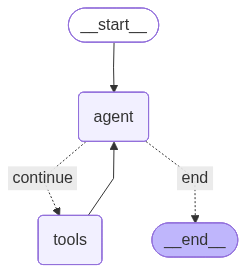

In [0]:
from agent import AGENT

# Exibir o draw_mermaid
from IPython.display import Image, display

display(Image(AGENT.agent.get_graph().draw_mermaid_png()))

In [0]:
# Determine Databricks resources to specify for automatic auth passthrough at deployment time
from agent import UC_TOOL_NAMES, VECTOR_SEARCH_TOOLS
import mlflow
from mlflow.models.resources import DatabricksFunction
from pkg_resources import get_distribution

resources = []
for tool in VECTOR_SEARCH_TOOLS:
    resources.extend(tool.resources)
for tool_name in UC_TOOL_NAMES:
    resources.append(DatabricksFunction(function_name=tool_name))

with mlflow.start_run():
    logged_agent_info = mlflow.pyfunc.log_model(
        name="agent",
        python_model="agent.py",
        pip_requirements=[
            "databricks-langchain",
            f"langgraph=={get_distribution('langgraph').version}",
            f"databricks-connect=={get_distribution('databricks-connect').version}",
        ],
        resources=resources,
    )

🔗 View Logged Model at: https://adb-864885279849395.15.azuredatabricks.net/ml/experiments/dac7ab84e928481dbefaee6d5f0f5ea6/models/m-fb4366ecd2b043d3bec41d10a8c1e853?o=864885279849395
2025/10/28 14:29:38 INFO mlflow.pyfunc: Predicting on input example to validate output


In [0]:
mlflow.models.predict(
    model_uri=f"runs:/{logged_agent_info.run_id}/agent",
    input_data={"input": [{"role": "user", "content": "What is 6*7 in Python?!"}]},
    env_manager="uv",
)

2025-10-28 14:29:50,002 6289 WARNING Unsuccessful download. Response status: 404, body: b'{\n  "error_code" : "NOT_FOUND",\n  "message" : "The file being accessed is not found.",\n  "details" : [ {\n    "@type" : "type.googleapis.com/google.rpc.ErrorInfo",\n    "reason" : "FILES_API_FILE_NOT_FOUND",\n    "domain" : "filesystem.databricks.com"\n  } ]\n}'


2025/10/28 14:29:51 INFO mlflow.models.flavor_backend_registry: Selected backend for flavor 'python_function'


2025-10-28 14:29:51,749 6289 WARNING Unsuccessful download. Response status: 404, body: b'{\n  "error_code" : "NOT_FOUND",\n  "message" : "The file being accessed is not found.",\n  "details" : [ {\n    "@type" : "type.googleapis.com/google.rpc.ErrorInfo",\n    "reason" : "FILES_API_FILE_NOT_FOUND",\n    "domain" : "filesystem.databricks.com"\n  } ]\n}'


2025/10/28 14:29:53 INFO mlflow.utils.virtualenv: Creating a new environment in /tmp/virtualenv_envs/mlflow-2b5edcceb3cc9072cb217c42cbc268cac14a6f4f with python version 3.12.3 using uv
Using CPython 3.12.3 interpreter at: /usr/bin/python3.12
Creating virtual environment at: /tmp/virtualenv_envs/mlflow-2b5edcceb3cc9072cb217c42cbc268cac14a6f4f
Activate with: source /tmp/virtualenv_envs/mlflow-2b5edcceb3cc9072cb217c42cbc268cac14a6f4f/bin/activate
2025/10/28 14:29:54 INFO mlflow.utils.virtualenv: Installing dependencies
Using Python 3.12.3 environment at: /tmp/virtualenv_envs/mlflow-2b5edcceb3cc9072cb217c42cbc268cac14a6f4f
Resolved 3 packages in 62ms
Prepared 3 packages in 94ms
Installed 3 packages in 16ms
 + pip==25.0.1
 + setuptools==75.8.0
 + wheel==0.45.1
Using Python 3.12.3 environment at: /tmp/virtualenv_envs/mlflow-2b5edcceb3cc9072cb217c42cbc268cac14a6f4f
Resolved 133 packages in 867ms
Prepared 132 packages in 3.65s
Installed 132 packages in 661ms
 + aiohappyeyeballs==2.6.1
 + aioht

{"object": "response", "output": [{"type": "function_call", "id": "run--1cee5a80-5434-4b4a-a237-32a3f3561176", "call_id": "toolu_bdrk_01P1nwAtPXjLChZud4nDZf5b", "name": "system__ai__python_exec", "arguments": "{\"code\": \"print(6 * 7)\"}"}, {"type": "function_call_output", "call_id": "toolu_bdrk_01P1nwAtPXjLChZud4nDZf5b", "output": "{\"format\": \"SCALAR\", \"value\": \"42\\n\"}"}, {"type": "message", "id": "run--ddc9dbcd-9ce4-4602-9a36-19b6a427cbbc", "content": [{"text": "The result of 6*7 in Python is 42.", "type": "output_text"}], "role": "assistant"}]}

2025/10/28 14:30:17 INFO mlflow.tracing.export.async_export_queue: Flushing the async trace logging queue before program exit. This may take a while...


In [0]:
mlflow.set_registry_uri("databricks-uc")

# TODO: define the catalog, schema, and model name for your UC model
model_name = "agentemodelo"
UC_MODEL_NAME = f"{catalog}.{schema}.{model_name}"

# register the model to UC
uc_registered_model_info = mlflow.register_model(model_uri=logged_agent_info.model_uri, name=UC_MODEL_NAME)

Registered model 'baraldi_catalog_new.genai.agentemodelo' already exists. Creating a new version of this model...
2025-10-28 14:30:21,332 6289 WARNING Unsuccessful download. Response status: 404, body: b'{\n  "error_code" : "NOT_FOUND",\n  "message" : "The file being accessed is not found.",\n  "details" : [ {\n    "@type" : "type.googleapis.com/google.rpc.ErrorInfo",\n    "reason" : "FILES_API_FILE_NOT_FOUND",\n    "domain" : "filesystem.databricks.com"\n  } ]\n}'


Uploading artifacts:   0%|          | 0/13 [00:00<?, ?it/s]

🔗 Created version '3' of model 'baraldi_catalog_new.genai.agentemodelo': https://adb-864885279849395.15.azuredatabricks.net/explore/data/models/baraldi_catalog_new/genai/agentemodelo/version/3?o=864885279849395


In [0]:
from databricks import agents

agents.deploy(
    UC_MODEL_NAME,
    uc_registered_model_info.version,
    tags={"endpointSource": "docs"},
)


    Deployment of baraldi_catalog_new.genai.agentemodelo version 3 initiated.  This can take up to 15 minutes and the Review App & Query Endpoint will not work until this deployment finishes.

    View status: https://adb-864885279849395.15.azuredatabricks.net/ml/endpoints/agents_baraldi_catalog_new-genai-agentemodelo/?o=864885279849395
    Review App: https://adb-864885279849395.15.azuredatabricks.net/ml/review-v2/chat?endpoint=agents_baraldi_catalog_new-genai-agentemodelo&o=864885279849395
    Monitor: https://adb-864885279849395.15.azuredatabricks.net/ml/experiments/dac7ab84e928481dbefaee6d5f0f5ea6?compareRunsMode=TRACES&o=864885279849395

You can refer back to the links above from the endpoint detail page at https://adb-864885279849395.15.azuredatabricks.net/ml/endpoints/agents_baraldi_catalog_new-genai-agentemodelo/?o=864885279849395.


Deployment(model_name='baraldi_catalog_new.genai.agentemodelo', model_version='3', endpoint_name='agents_baraldi_catalog_new-genai-agentemodelo', served_entity_name='baraldi_catalog_new-genai-agentemodelo_3', query_endpoint='https://adb-864885279849395.15.azuredatabricks.net/serving-endpoints/agents_baraldi_catalog_new-genai-agentemodelo/served-models/baraldi_catalog_new-genai-agentemodelo_3/invocations?o=864885279849395', endpoint_url='https://adb-864885279849395.15.azuredatabricks.net/ml/endpoints/agents_baraldi_catalog_new-genai-agentemodelo/?o=864885279849395', review_app_url='https://adb-864885279849395.15.azuredatabricks.net/ml/review-v2/chat?endpoint=agents_baraldi_catalog_new-genai-agentemodelo&o=864885279849395')

### Request e Feedback
![Screenshot 2025-10-29 at 17.22.18.png](./Images/screen03.png "Screenshot 2025-10-29 at 17.22.18.png")
![Screenshot 2025-10-29 at 17.14.15.png](./Images/screen01.png "Screenshot 2025-10-29 at 17.14.15.png")
![Screenshot 2025-10-29 at 17.19.22.png](./Images/screen02.png "Screenshot 2025-10-29 at 17.19.22.png")

### Request em endpoint e monitoramento em tabela do sistema junto a guardrails com as respostas formatadas

In [0]:
from openai import OpenAI
import os
import getpass

# How to get your Databricks token: https://docs.databricks.com/en/dev-tools/auth/pat.html
DATABRICKS_TOKEN = getpass.getpass('Insira seu token Databricks: ')
# Alternatively in a Databricks notebook you can use this:
# DATABRICKS_TOKEN = dbutils.notebook.entry_point.getDbutils().notebook().getContext().apiToken().get()

client = OpenAI(
    api_key=DATABRICKS_TOKEN,
    base_url="https://adb-864885279849395.15.azuredatabricks.net/serving-endpoints"
)

response = client.responses.create(
    model="agents_baraldi_catalog_new-genai-agentemodelo",
    input=[
        {
            "role": "user",
            "content": "Oi, tudo bem? O que é o Databricks?"
        }
    ]
)

print(response)

Insira seu token Databricks:  [REDACTED]

Response(id='b0dafeb2-afca-4809-b17a-b54ec41ab6f8', created_at=None, error=None, incomplete_details=None, instructions=None, metadata=None, model=None, object='response', output=[ResponseFunctionToolCall(arguments='{"code": "# Informa\\u00e7\\u00f5es sobre o Databricks em portugu\\u00eas\\nprint(\\"\\"\\"\\n# Databricks\\n\\nO Databricks \\u00e9 uma plataforma de an\\u00e1lise de dados baseada em nuvem fundada pelos criadores do Apache Spark. Principais caracter\\u00edsticas:\\n\\n1. **Origem**: Foi fundada em 2013 por Ali Ghodsi, Andy Konwinski, Ion Stoica, Matei Zaharia, Patrick Wendell, Reynold Xin e Scott Shenker, que eram os desenvolvedores originais do Apache Spark na UC Berkeley.\\n\\n2. **Funcionalidades principais**:\\n   - Ambiente unificado para processamento de big data e machine learning\\n   - Suporte nativo ao Apache Spark\\n   - Notebooks colaborativos para an\\u00e1lise de dados\\n   - Integra\\u00e7\\u00e3o com diversas linguagens: Python, R, SQL, Scala\\n   - Gerenci

![Screenshot 2025-10-29 at 17.52.14.png](./Images/screen05.png "Screenshot 2025-10-29 at 17.52.14.png")
![Screenshot 2025-10-29 at 17.48.00.png](./Images/screen04.png "Screenshot 2025-10-29 at 17.48.00.png")
![Screenshot 2025-10-30 at 13.04.32.png](./Images/screen06.png "Screenshot 2025-10-30 at 13.04.32.png")